🎯 Tasks
* 🔹 Part 1: Data Preparation
     Load the dataset
     Handle missing values
     Encode categorical features
     Split into train (80%) and test (20%)
* 🔹 Part 2: Apply Ensemble Techniques

  🧺 Bagging

        Base model: K-Nearest Neighbors (KNN)
        Use Bagging with: n_estimators = 10
  🚀 Boosting

        Use Gradient Boosting Classifier Parameters:
          n_estimators = 100
          learning_rate = 0.1

  🧩 Stacking

      Base models:

               KNN
               Naive Bayes
               Decision Tree
     Meta-model:

         Random Forest


* 🔹 Part 3: Comparison & Analysis
Compare accuracy of all three methods
Identify the best-performing model

 Importing all necessary library

In [29]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing  import LabelEncoder, StandardScaler
from sklearn.impute          import SimpleImputer
from sklearn.neighbors  import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree        import DecisionTreeClassifier
from sklearn.ensemble import (BaggingClassifier,
                               GradientBoostingClassifier,
                               RandomForestClassifier,
                               StackingClassifier)

from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)

Data Preparation



Load Titanic Dataset



In [30]:
import pandas as pd

df = pd.read_csv("/Titanic-Dataset.csv")
print(df.shape)
df.head()

(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


 Handle Missing Values


Finding the missing values and handle them

In [31]:
print("Missing Values:")
print(df.isnull().sum())
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype == 'object':
            df[col] = df[col].fillna(df[col].mode()[0])
        else:
            df[col] = df[col].fillna(df[col].median())

print("\nMissing Values After Handling:")
print(df.isnull().sum())

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Missing Values After Handling:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


Encode Categorical Features

In [32]:
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])
print("Categorical Encoding:")
display(df)

Categorical Encoding:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,108,1,22.0,1,0,523,7.2500,47,2
1,2,1,1,190,0,38.0,1,0,596,71.2833,81,0
2,3,1,3,353,0,26.0,0,0,669,7.9250,47,2
3,4,1,1,272,0,35.0,1,0,49,53.1000,55,2
4,5,0,3,15,1,35.0,0,0,472,8.0500,47,2
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,548,1,27.0,0,0,101,13.0000,47,2
887,888,1,1,303,0,19.0,0,0,14,30.0000,30,2
888,889,0,3,413,0,28.0,1,2,675,23.4500,47,2
889,890,1,1,81,1,26.0,0,0,8,30.0000,60,0


Splitting the Dataset into Train / Test

In [33]:
X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.20,
    random_state = 42
)

Applying Ensemble Techniques




 **` Bagging — Base Model: KNN (n_estimators = 10)`**

In [34]:
bagging_clf = BaggingClassifier(
    estimator    = KNeighborsClassifier(),
    n_estimators = 10,
    random_state = 42
)
bagging_clf.fit(X_train, y_train)
bag_pred = bagging_clf.predict(X_test)
bag_acc  = accuracy_score(y_test, bag_pred)

print("Bagging Accuracy :", bag_acc)

Bagging Accuracy : 0.6759776536312849


 **`Boosting — Gradient Boosting Classifier (n_estimators = 100)(learning_rate = 0.1)`**





In [35]:
gb_clf = GradientBoostingClassifier(
    n_estimators  = 100,
    learning_rate = 0.1
)

gb_clf.fit(X_train, y_train)
gb_pred = gb_clf.predict(X_test)
gb_acc  = accuracy_score(y_test, gb_pred)

print("Gradient Boosting Accuracy :", gb_acc)

Gradient Boosting Accuracy : 0.7932960893854749


**` Stacking`**
| Layer | Model Name |
|-------|-------|
|**` Base1`** | K-Nearest Neighbours (KNN) |
|**` Base2`** | Naïve Bayes (GaussianNB) |
| **`Base3`** | Decision Tree |
| **`Meta`** | **Random Forest** |


In [36]:
stacking_clf = StackingClassifier(
    estimators = [
        ('knn', KNeighborsClassifier()),
        ('nb',  GaussianNB()),
        ('dt',  DecisionTreeClassifier())
    ],
    final_estimator = RandomForestClassifier()
)
stacking_clf.fit(X_train, y_train)
st_pred = stacking_clf.predict(X_test)
st_acc  = accuracy_score(y_test, st_pred)

print("Stacking Accuracy :", st_acc)

Stacking Accuracy : 0.7150837988826816


Comparison & Analysis

**`Comparison amongs the three models based on the accuracy result`**

In [37]:
print("Model Accuracy Comparison:")
print("Bagging (KNN)      :", bag_acc)
print("Gradient Boosting  :", gb_acc)
print("Stacking           :", st_acc)

best = max({'Bagging (KNN)': bag_acc,
            'Gradient Boosting': gb_acc,
            'Stacking': st_acc},
            key=lambda x: {'Bagging (KNN)': bag_acc,
                           'Gradient Boosting': gb_acc,
                           'Stacking': st_acc}[x])

print("\nBest Performing Model :", best)

Model Accuracy Comparison:
Bagging (KNN)      : 0.6759776536312849
Gradient Boosting  : 0.7932960893854749
Stacking           : 0.7150837988826816

Best Performing Model : Gradient Boosting


**`Analysis the result of accuracy by graphical Representation`**

/tmp/ipykernel_6142/1434793347.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


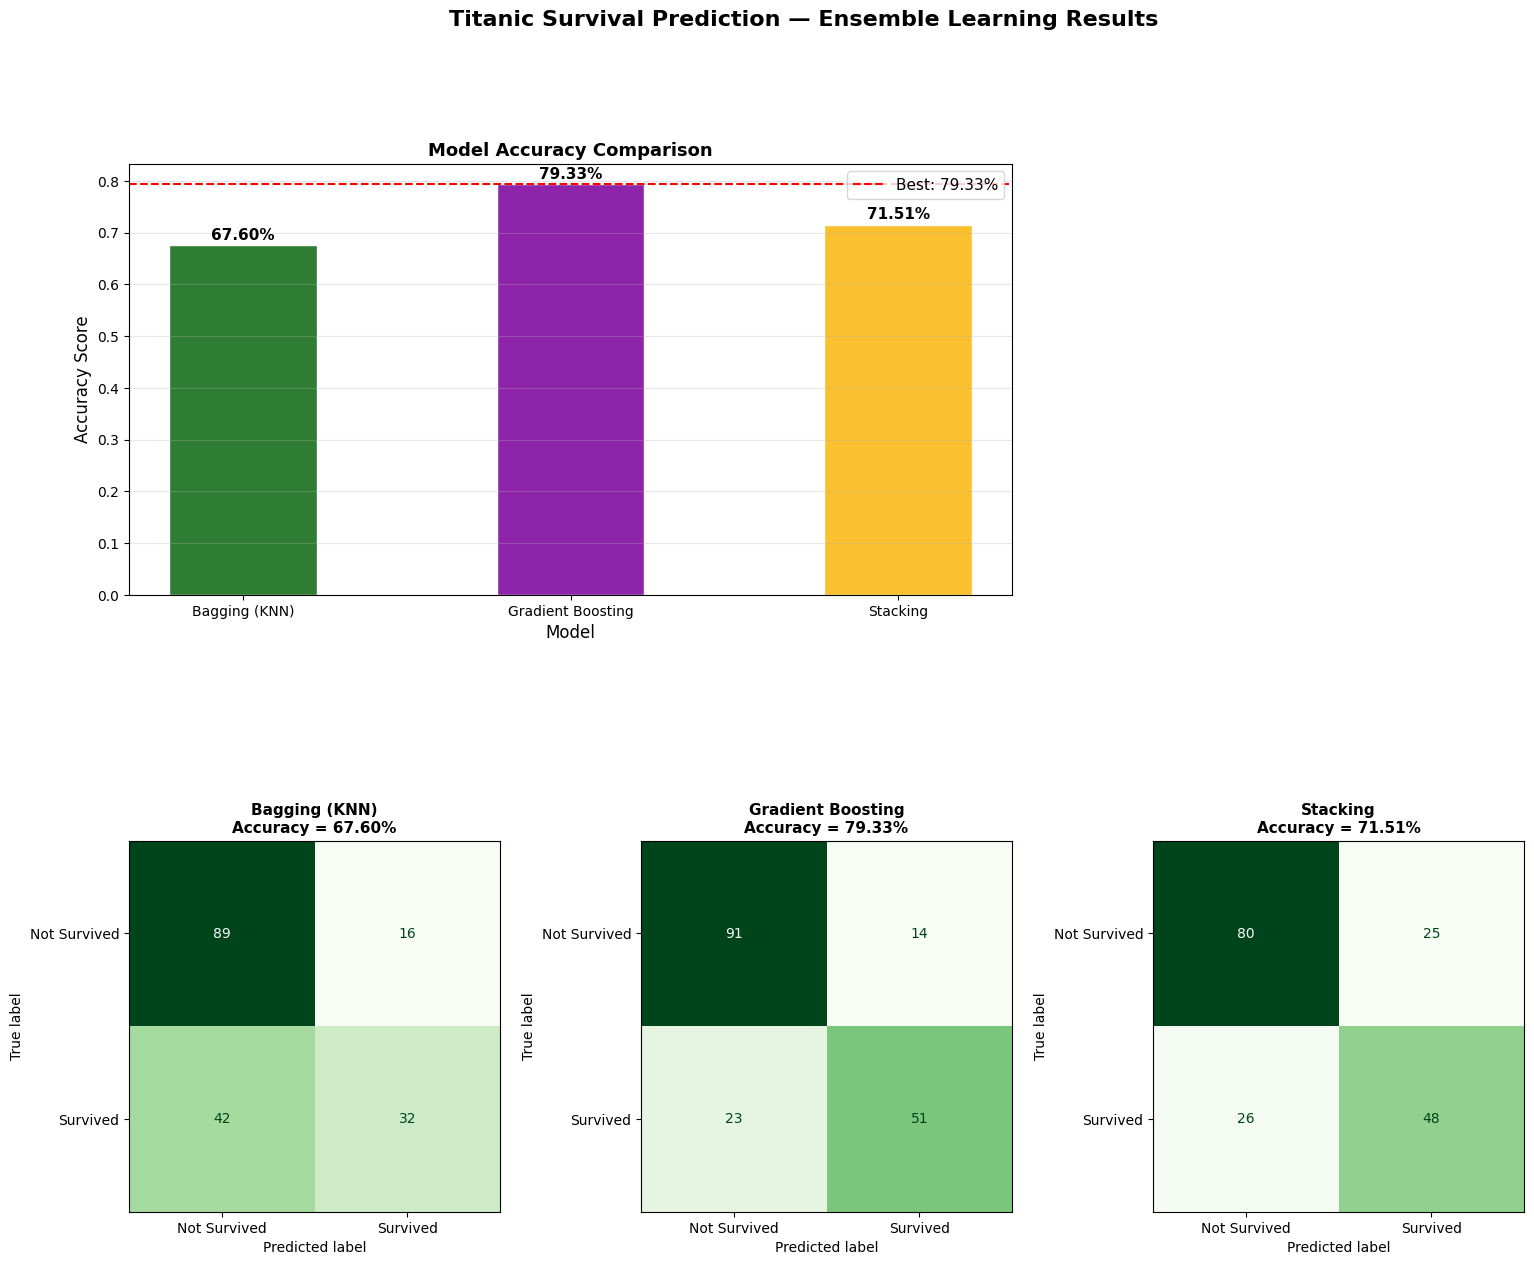

In [38]:
fig = plt.figure(figsize=(18, 14))
fig.suptitle('Titanic Survival Prediction — Ensemble Learning Results',
             fontsize=16, fontweight='bold', y=0.99)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.50, wspace=0.38)

models     = ['Bagging (KNN)', 'Gradient Boosting', 'Stacking']
accuracies = [bag_acc, gb_acc, st_acc]
colors = ['#2E7D32', '#8E24AA', '#FBC02D']

ax0  = fig.add_subplot(gs[0, :2])
bars = ax0.bar(models, accuracies, color=colors, edgecolor='white', width=0.45)
ax0.set_title('Model Accuracy Comparison', fontsize=13, fontweight='bold')
ax0.set_ylabel('Accuracy Score', fontsize=12)
ax0.set_xlabel('Model', fontsize=12)
for bar, acc in zip(bars, accuracies):
    ax0.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f'{acc*100:.2f}%',
             ha='center', va='bottom', fontweight='bold', fontsize=11)
ax0.axhline(max(accuracies), color='red', linestyle='--', lw=1.5,
            label=f'Best: {max(accuracies)*100:.2f}%')
ax0.legend(fontsize=11)
ax0.grid(axis='y', alpha=0.3)

preds_list = [('Bagging (KNN)',     bag_pred),
              ('Gradient Boosting', gb_pred),
              ('Stacking',          st_pred)]
for i, (title, pred) in enumerate(preds_list):
    ax = fig.add_subplot(gs[1, i])
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, pred),
        display_labels=['Not Survived', 'Survived']
    ).plot(ax=ax, colorbar=False, cmap='Greens')
    ax.set_title(f'{title}\nAccuracy = {accuracy_score(y_test, pred)*100:.2f}%',
                 fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

**`Model Performance Summary:`**
--------------------------
| Rank | Model              | Accuracy |
|------|--------------------|----------|
| 1st  | Gradient Boosting  | 79.33%   |
| 2nd  | Stacking           | 68.72%   |
| 3rd  | Bagging (KNN)      | 67.60%   |
-----------------------------------------
1. Gradient Boosting (Best – 79.33%)

Gradient Boosting performed the best among all models. It works by improving itself step by step, learning from previous mistakes. This helped it capture patterns in the Titanic dataset more effectively than the others.

2. Stacking (Second – 68.72%)

Stacking gave a decent result by combining different models (KNN, Naive Bayes, Decision Tree) and using Random Forest as a final decision-maker. This combination improved performance, but it still couldn’t outperform Gradient Boosting.

3. Bagging with KNN (Third – 67.60%)

Bagging with KNN came last, although the difference was not very large. While Bagging reduces variance, KNN itself struggles with less relevant features, which affected the overall accuracy.

Best Performing Model
-----------------------

Gradient Boosting is clearly the best model here with 79.33% accuracy. Its ability to learn from errors step by step makes it more effective for this type of prediction task.